# Regressão Logística — Baseline
Validação temporal por expanding window (sempre testando em 2024).
Métricas prioritárias: **Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1**

In [23]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
)

BASE_DIR    = '../../data/features/baseline'
OUTPUT_MOD  = '../../output/modelos'
OUTPUT_MET  = '../../output/metricas'
ALGO        = 'logistic_regression'
DATASET     = 'baseline'
RANDOM_STATE = 42

## 1. Carregamento dos dados

In [24]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

with open(os.path.join(BASE_DIR, 'config.json')) as f:
    config = json.load(f)

TRAIN_YEARS = config['train_years']
YEAR_COL    = config['split_col']

print(f'X_train: {X_train.shape} | y_train óbitos: {int(y_train.sum()):,} ({y_train.mean()*100:.2f}%)')
print(f'X_test:  {X_test.shape}  | y_test  óbitos: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)')

X_train: (137743, 52) | y_train óbitos: 2,640 (1.92%)
X_test:  (160534, 52)  | y_test  óbitos: 5,295 (3.30%)


## 2. Preprocessamento

In [25]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        # Sinais de alarme/gravidade: NaN informativo → 0
        ('alrm_grav',
         SimpleImputer(strategy='constant', fill_value=0),
         ALRM_COLS + GRAV_COLS),

        # Sintomas binários: NaN residual → moda
        ('sintomas',
         SimpleImputer(strategy='most_frequent'),
         SYMP_COLS),

        # Idade: outlier > 120 → NaN → mediana → escala
        ('age',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['age_years']),

        # epi_week: mediana → escala
        ('epi',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['epi_week']),

        # CS_SEXO: encode F→0/M→1 → moda
        ('sexo',
         Pipeline([
             ('enc', OrdinalEncoder(categories=[['F','M']],
                                    handle_unknown='use_encoded_value',
                                    unknown_value=np.nan)),
             ('imp', SimpleImputer(strategy='most_frequent')),
         ]),
         ['CS_SEXO']),

        # CS_ESCOL_N: ordinal com ordem natural (0=sem escolaridade … 7=superior completo)
        ('escol',
         Pipeline([
             ('imp', SimpleImputer(strategy='median')),
             ('scl', StandardScaler()),
         ]),
         ['CS_ESCOL_N']),

        # CS_RACA: categórica nominal — one-hot (sem ordem entre raças)
        ('raca',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_RACA']),

        # CS_GESTANT: categórica com categorias especiais — one-hot
        ('gestant',
         Pipeline([
             ('imp', SimpleImputer(strategy='most_frequent')),
             ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         ['CS_GESTANT']),

        # SG_UF: encode ordinal (sem ordem semântica, mas baixo impacto em LR)
        ('uf',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ['SG_UF']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print('Preprocessador definido.')

Preprocessador definido.


## 3. Funções auxiliares

In [26]:
def calcular_metricas(y_true, y_pred_proba, threshold=0.5, label=''):
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'label':          label,
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_pred_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_pred_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
        'threshold':      threshold,
        'n_train':        None,
        'n_obito_train':  None,
    }

def build_pipeline():
    return Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
            solver='lbfgs',
        )),
    ])

def prep_X(df):
    """Clipa age_years e dropa year antes do fit/transform."""
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

print('Funções definidas.')

Funções definidas.


## 4. Expanding window — validação temporal
Treino acumulado sobre anos anteriores, teste sempre em 2024.

In [27]:
X_test_prep = prep_X(X_test)
resultados  = []

for i in range(1, len(TRAIN_YEARS) + 1):
    anos_treino = TRAIN_YEARS[:i]
    label = '+'.join(str(a) for a in anos_treino)

    mask = X_train[YEAR_COL].isin(anos_treino)
    X_w  = prep_X(X_train[mask])
    y_w  = y_train[mask].dropna()
    X_w  = X_w.loc[y_w.index]

    pipe = build_pipeline()
    pipe.fit(X_w, y_w)

    proba = pipe.predict_proba(X_test_prep)[:, 1]
    y_te  = y_test.dropna()
    proba = proba[y_test.notna().values]

    metricas = calcular_metricas(y_te, proba, label=label)
    metricas['n_train']       = len(X_w)
    metricas['n_obito_train'] = int(y_w.sum())
    resultados.append(metricas)

    print(f'[{label}] Sensibilidade={metricas["sensibilidade"]:.4f} | '
          f'AUPRC={metricas["auprc"]:.4f} | ROC-AUC={metricas["roc_auc"]:.4f}')

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

[2020] Sensibilidade=0.7870 | AUPRC=0.6067 | ROC-AUC=0.9164
[2020+2021] Sensibilidade=0.7962 | AUPRC=0.6117 | ROC-AUC=0.9186
[2020+2021+2022] Sensibilidade=0.7989 | AUPRC=0.6236 | ROC-AUC=0.9219
[2020+2021+2022+2023] Sensibilidade=0.8004 | AUPRC=0.6250 | ROC-AUC=0.9242


,label,sensibilidade,especificidade,auprc,roc_auc,f1,precisao,threshold,n_train,n_obito_train
0,2020,0.7870,0.8753,0.6067,0.9164,0.2892,0.1771,0.5,26955,496
1,2020+2021,0.7962,0.8743,0.6117,0.9186,0.2904,0.1776,0.5,50305,724
2,2020+2021+2022,0.7989,0.8813,0.6236,0.9219,0.3026,0.1867,0.5,92900,1619
3,2020+2021+2022+2023,0.8004,0.8853,0.6250,0.9242,0.3100,0.1922,0.5,137743,2640


## 5. Evolução das métricas por janela de treino

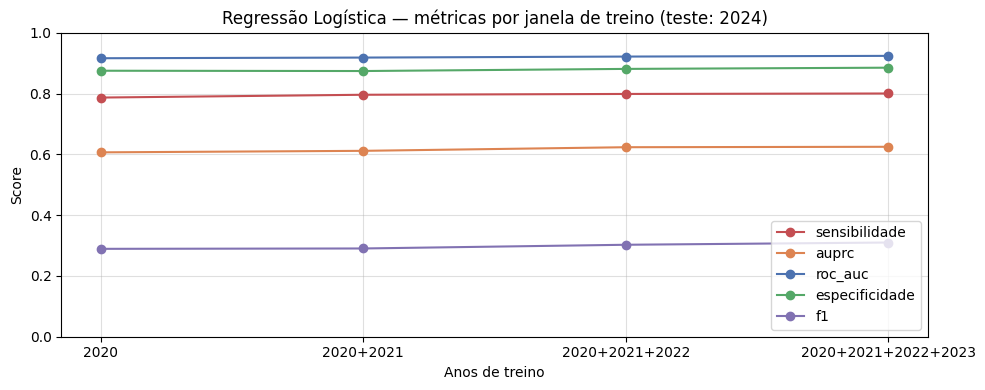

In [28]:
metricas_plot = ['sensibilidade','auprc','roc_auc','especificidade','f1']
cores = ['#C44E52','#DD8452','#4C72B0','#55A868','#8172B2']

fig, ax = plt.subplots(figsize=(10, 4))
for metrica, cor in zip(metricas_plot, cores):
    ax.plot(df_resultados['label'], df_resultados[metrica],
            marker='o', label=metrica, color=cor)

ax.set_title('Regressão Logística — métricas por janela de treino (teste: 2024)')
ax.set_xlabel('Anos de treino')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Modelo final — treino em 2020–2023, avaliação em 2024

In [29]:
X_train_final = prep_X(X_train)
y_train_final = y_train.dropna()
X_train_final = X_train_final.loc[y_train_final.index]

pipeline_final = build_pipeline()
pipeline_final.fit(X_train_final, y_train_final)

proba_final = pipeline_final.predict_proba(X_test_prep)[:, 1]
y_te        = y_test.dropna()
proba_final = proba_final[y_test.notna().values]

metricas_final = calcular_metricas(y_te, proba_final, label='2020-2023')
metricas_final['n_train']       = len(X_train_final)
metricas_final['n_obito_train'] = int(y_train_final.sum())

print('=== Modelo final (2020–2023 → 2024) ===')
for k, v in metricas_final.items():
    print(f'  {k}: {v}')

=== Modelo final (2020–2023 → 2024) ===
  label: 2020-2023
  sensibilidade: 0.8004
  especificidade: 0.8853
  auprc: 0.625
  roc_auc: 0.9242
  f1: 0.31
  precisao: 0.1922
  threshold: 0.5
  n_train: 137743
  n_obito_train: 2640


              precision    recall  f1-score   support

        Cura       0.99      0.89      0.94    155239
       Óbito       0.19      0.80      0.31      5295

    accuracy                           0.88    160534
   macro avg       0.59      0.84      0.62    160534
weighted avg       0.97      0.88      0.92    160534



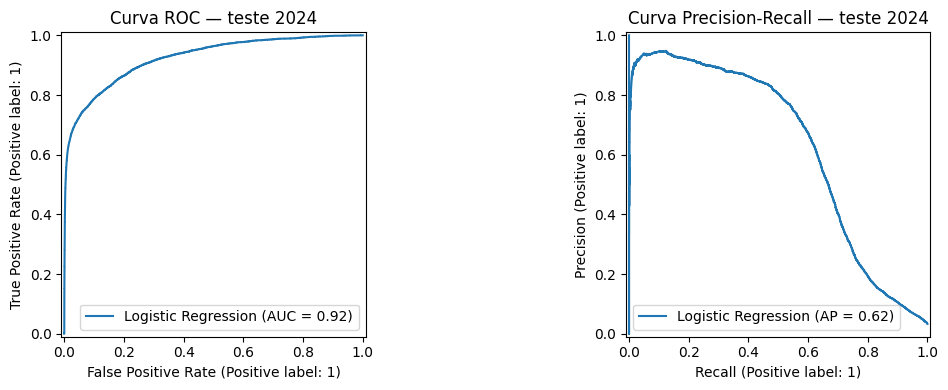

In [30]:
print(classification_report(y_te, (proba_final >= 0.5).astype(int),
                             target_names=['Cura','Óbito']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_te, proba_final, ax=axes[0],
                                  name='Logistic Regression')
axes[0].set_title('Curva ROC — teste 2024')

PrecisionRecallDisplay.from_predictions(y_te, proba_final, ax=axes[1],
                                         name='Logistic Regression')
axes[1].set_title('Curva Precision-Recall — teste 2024')
plt.tight_layout()
plt.show()

### Matriz de Confusão (threshold = 0.5)

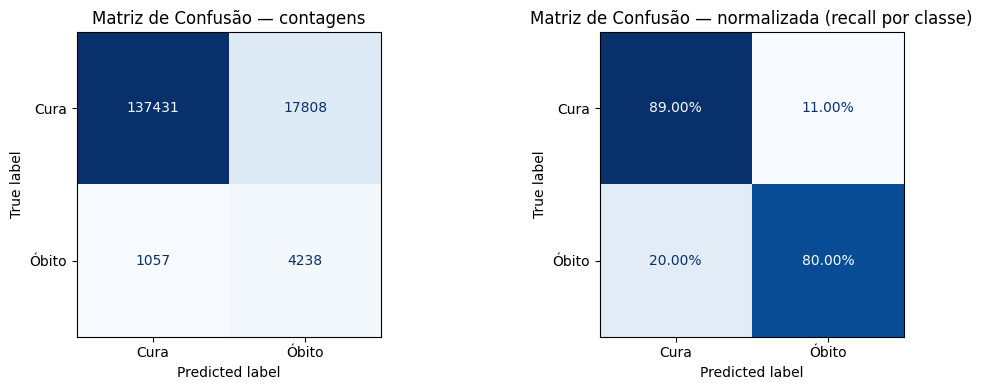

VP (óbitos detectados):   4,238
FN (óbitos perdidos):     1,057
FP (falsos alarmes):      17,808
VN (curas classificadas): 137,431


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_05 = (proba_final >= 0.5).astype(int)
cm = confusion_matrix(y_te, y_pred_05)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Contagens absolutas
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cura', 'Óbito'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — contagens')

# Normalizada por linha (recall por classe)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Cura', 'Óbito'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — normalizada (recall por classe)')
for text in axes[1].texts:
    text.set_text(f'{float(text.get_text()):.2%}')

plt.tight_layout()
plt.show()

print(f'VP (óbitos detectados):   {tp:,}')
print(f'FN (óbitos perdidos):     {fn:,}')
print(f'FP (falsos alarmes):      {fp:,}')
print(f'VN (curas classificadas): {tn:,}')

## 6.1 Análise de threshold

Threshold padrão  (0.50): sensibilidade=0.8004 | especificidade=0.8853
Threshold Youden  (0.55): sensibilidade=0.7766 | especificidade=0.9096
Threshold sens≥90% (0.30): sensibilidade=0.9024 | especificidade=0.7334


,threshold,sensibilidade,especificidade,precisao,f1,tp,fp,fn,tn
0,0.05,0.9960,0.1447,0.0382,0.0736,5274,132782,21,22457
1,0.10,0.9800,0.3806,0.0512,0.0973,5189,96152,106,59087
2,0.15,0.9609,0.5148,0.0633,0.1187,5088,75317,207,79922
3,0.20,0.9405,0.6063,0.0753,0.1395,4980,61123,315,94116
4,0.25,0.9229,0.6772,0.0889,0.1621,4887,50109,408,105130
5,0.30,0.9024,0.7334,0.1035,0.1857,4778,41379,517,113860
6,0.35,0.8765,0.7817,0.1204,0.2118,4641,33890,654,121349
7,0.40,0.8514,0.8222,0.1404,0.2411,4508,27595,787,127644
8,0.45,0.8238,0.8560,0.1633,0.2725,4362,22353,933,132886
9,0.50,0.8004,0.8853,0.1922,0.3100,4238,17808,1057,137431


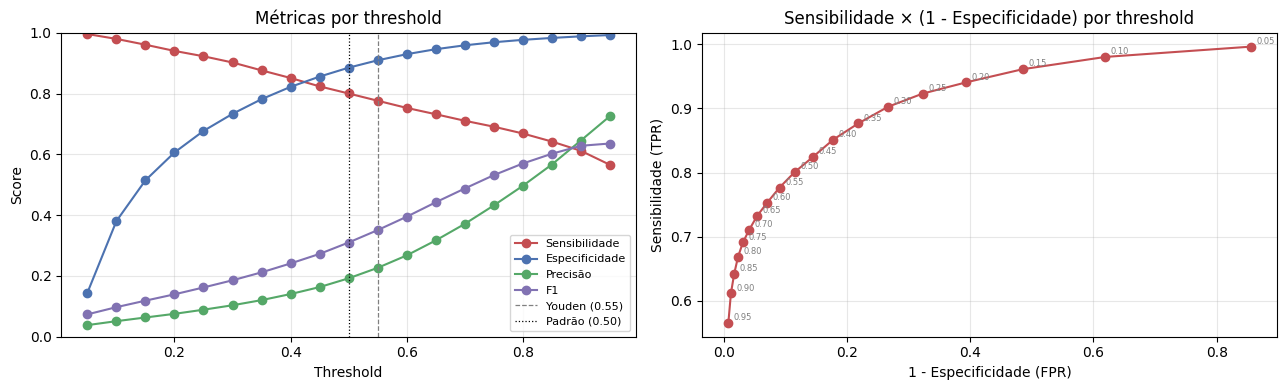

In [32]:
thresholds = np.arange(0.05, 0.96, 0.05)
rows = []

for t in thresholds:
    y_pred = (proba_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    rows.append({
        'threshold':      round(t, 2),
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'precisao':       round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
        'f1':             round(f1_score(y_te, y_pred), 4),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    })

df_thresh = pd.DataFrame(rows)

# Threshold ótimo pelo índice de Youden (sensibilidade + especificidade - 1)
df_thresh['youden'] = df_thresh['sensibilidade'] + df_thresh['especificidade'] - 1
idx_youden = df_thresh['youden'].idxmax()

# Threshold com sensibilidade >= 0.90 e maior especificidade
high_sens = df_thresh[df_thresh['sensibilidade'] >= 0.90]
idx_90 = high_sens['especificidade'].idxmax() if not high_sens.empty else None

print(f"Threshold padrão  (0.50): sensibilidade={df_thresh.loc[df_thresh['threshold']==0.50, 'sensibilidade'].values[0]:.4f} | especificidade={df_thresh.loc[df_thresh['threshold']==0.50, 'especificidade'].values[0]:.4f}")
print(f"Threshold Youden  ({df_thresh.loc[idx_youden,'threshold']:.2f}): sensibilidade={df_thresh.loc[idx_youden,'sensibilidade']:.4f} | especificidade={df_thresh.loc[idx_youden,'especificidade']:.4f}")
if idx_90 is not None:
    print(f"Threshold sens≥90% ({df_thresh.loc[idx_90,'threshold']:.2f}): sensibilidade={df_thresh.loc[idx_90,'sensibilidade']:.4f} | especificidade={df_thresh.loc[idx_90,'especificidade']:.4f}")

display(df_thresh.drop(columns='youden'))

# Gráfico tradeoff
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df_thresh['threshold'], df_thresh['sensibilidade'], 'o-', color='#C44E52', label='Sensibilidade')
axes[0].plot(df_thresh['threshold'], df_thresh['especificidade'], 'o-', color='#4C72B0', label='Especificidade')
axes[0].plot(df_thresh['threshold'], df_thresh['precisao'],       'o-', color='#55A868', label='Precisão')
axes[0].plot(df_thresh['threshold'], df_thresh['f1'],             'o-', color='#8172B2', label='F1')
axes[0].axvline(df_thresh.loc[idx_youden, 'threshold'], color='gray', linestyle='--', linewidth=0.9, label=f'Youden ({df_thresh.loc[idx_youden,"threshold"]:.2f})')
axes[0].axvline(0.5, color='black', linestyle=':', linewidth=0.9, label='Padrão (0.50)')
axes[0].set_title('Métricas por threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Curva sensibilidade × especificidade
axes[1].plot(1 - df_thresh['especificidade'], df_thresh['sensibilidade'], 'o-', color='#C44E52')
for _, row in df_thresh.iterrows():
    axes[1].annotate(f"{row['threshold']:.2f}",
                     (1 - row['especificidade'], row['sensibilidade']),
                     textcoords='offset points', xytext=(4, 2), fontsize=6, color='gray')
axes[1].set_title('Sensibilidade × (1 - Especificidade) por threshold')
axes[1].set_xlabel('1 - Especificidade (FPR)')
axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6.2 Importância das features — coeficientes

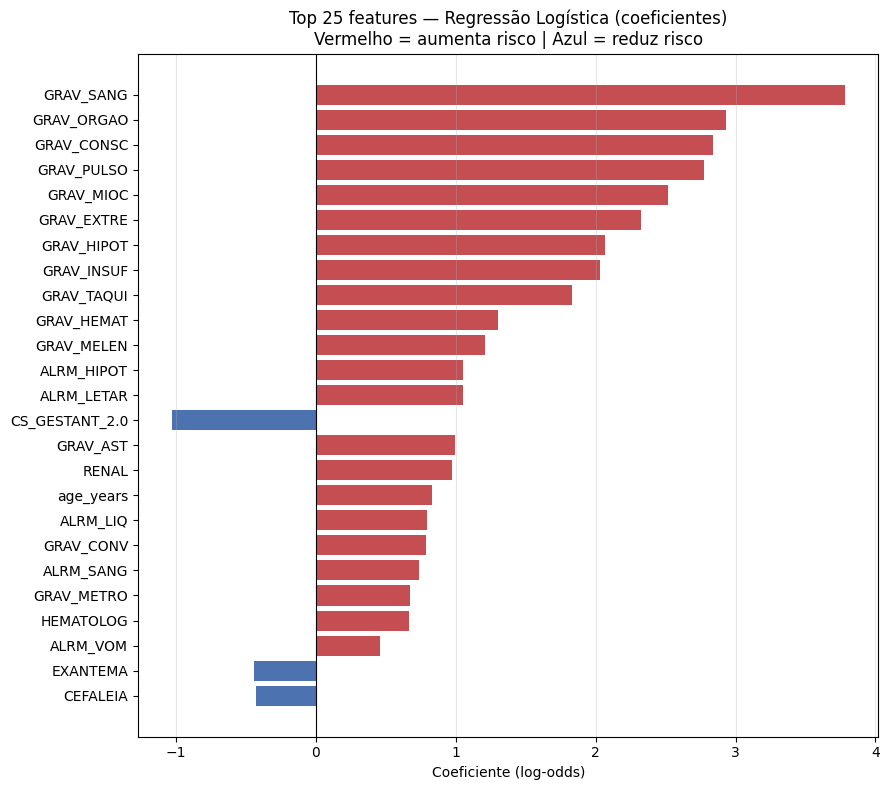

,feature,coeficiente,abs
19,GRAV_SANG,3.780012,3.780012
23,GRAV_ORGAO,2.930836,2.930836
22,GRAV_CONSC,2.836998,2.836998
9,GRAV_PULSO,2.776070,2.776070
21,GRAV_MIOC,2.514077,2.514077
14,GRAV_EXTRE,2.321977,2.321977
15,GRAV_HIPOT,2.068275,2.068275
12,GRAV_INSUF,2.029915,2.029915
13,GRAV_TAQUI,1.833703,1.833703
16,GRAV_HEMAT,1.297880,1.297880


In [33]:
feature_names = pipeline_final['pre'].get_feature_names_out()
coefs         = pipeline_final['clf'].coef_[0]

df_coef = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs})
df_coef['abs'] = df_coef['coeficiente'].abs()
df_coef = df_coef.sort_values('abs', ascending=False)

top_n  = 25
df_top = df_coef.head(top_n)

fig, ax = plt.subplots(figsize=(9, 8))
cores_bar = ['#C44E52' if c > 0 else '#4C72B0' for c in df_top['coeficiente'][::-1]]
ax.barh(df_top['feature'][::-1], df_top['coeficiente'][::-1], color=cores_bar)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} features — Regressão Logística (coeficientes)\nVermelho = aumenta risco | Azul = reduz risco')
ax.set_xlabel('Coeficiente (log-odds)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(df_coef.head(15)[['feature', 'coeficiente', 'abs']])

## 7. Salvamento

In [34]:
os.makedirs(OUTPUT_MOD, exist_ok=True)
os.makedirs(OUTPUT_MET, exist_ok=True)

model_path = os.path.join(OUTPUT_MOD, f'{ALGO}_{DATASET}.joblib')
joblib.dump(pipeline_final, model_path)
print(f'Modelo salvo: {model_path}')

# Métricas do expanding window
met_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}.parquet')
df_resultados.to_parquet(met_path, index=False)
print(f'Métricas salvas: {met_path}')

# Predições do modelo final
df_pred = pd.DataFrame({'y_true': y_te.values, 'y_proba': proba_final})
pred_path = os.path.join(OUTPUT_MET, f'{ALGO}_{DATASET}_predicoes.parquet')
df_pred.to_parquet(pred_path, index=False)
print(f'Predições salvas: {pred_path}')

Modelo salvo: ../../output/modelos/logistic_regression_baseline.joblib
Métricas salvas: ../../output/metricas/logistic_regression_baseline.parquet
Predições salvas: ../../output/metricas/logistic_regression_baseline_predicoes.parquet
